In [1]:
import matplotlib.pyplot as plt
import numpy as np
import control
from numpy import sin, cos, tan, pi
from control import TransferFunction as TF

In [ ]:
pip install control

<img src="../../345_images/tikz_drawings/msd_drawings/vertical_msd/vert_spring_and_damper_case_2.png" width=200px>

## Problem Statement

Find the response of the system above to an initial displacement of $y_0$

## Make up some numbers

In [4]:
y0 = 2
m = 1.5
k = 50
b = 3

## Laplace Solution

In [5]:
b_cr = 2*np.sqrt(k*m)

In [7]:
zeta = b/b_cr
zeta

np.float64(0.1732050807568877)

In [11]:
wn = np.sqrt(k/m)
wn

np.float64(5.773502691896258)

In [12]:
a = zeta*wn
a

np.float64(0.9999999999999999)

In [13]:
wd = wn*np.sqrt(1-zeta**2)
wd

np.float64(5.686240703077328)

In [14]:
C2 = y0

In [15]:
C1 = (y0/wd)*(b/m-a)

### Create Time Vector

In [17]:
t = np.arange(0,5,0.01)

In [18]:
y_laplace = np.exp(-a*t)*(C1*np.sin(wd*t) + C2*np.cos(wd*t))

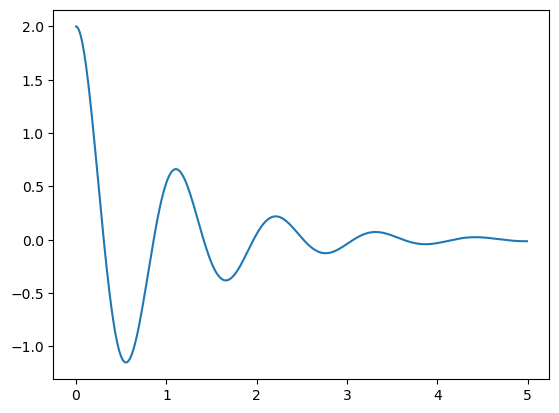

In [19]:
plt.figure()
plt.plot(t,y_laplace)

In [20]:
y0

2

In [23]:
from scipy.integrate import odeint

In [30]:
def dydt(y, t):
    x1 = y[0]
    x2 = y[1]
    x1dot = x2
    x2dot = 1/m*(-b*x2-k*x1)
    return [x1dot, x2dot]

In [31]:
out = odeint(dydt, [y0,0], t)

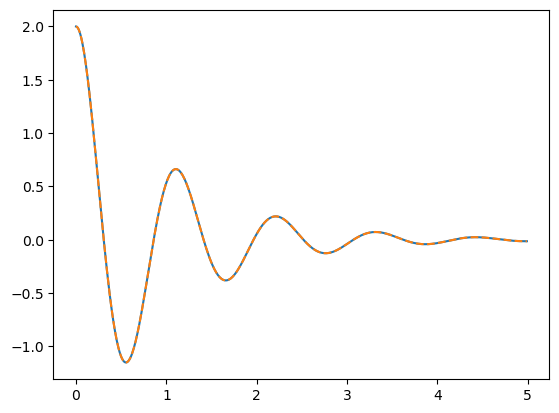

In [32]:
plt.figure()
plt.plot(t,y_laplace)
plt.plot(t, out[:,0], '--')